## BLIP VQA base: Yes/No benchmark with task-aware metrics (Accuracy, Macro-F1, coverage, confusion)


It writes outputs to out/blip_yesno_forced_choice/

It reads from 0_dataset_prep/out/metadata/colonoscopy_metadata.csv amd 0_dataset_prep/out/images/

In [1]:
import os, re, json, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support, confusion_matrix

## Path (Added smart path resolution)
(works no matter where we run notebook)

In [2]:
def find_dataset_root() -> Path:
    start = Path.cwd().resolve()
    for p in [start] + list(start.parents):
        if (p / "0_dataset_prep").exists():
            return p
    raise RuntimeError(f"Could not locate dataset root (folder containing '0_dataset_prep'). cwd={start}")

ROOT = find_dataset_root()

CSV_PATH   = ROOT / "0_dataset_prep" / "out" / "metadata" / "colonoscopy_metadata.csv"
IMAGES_DIR = ROOT / "0_dataset_prep" / "out" / "images"
SPLIT_FILE = ROOT / "0_dataset_prep" / "out" / "splits" / "split_v1_image_level.csv"  # optional

OUT_DIR = ROOT / "4_VQA_transformers" / "out" / "blip_yesno_forced_choice"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("ROOT:", ROOT)
print("CSV_PATH:", CSV_PATH)
print("IMAGES_DIR:", IMAGES_DIR)
print("SPLIT_FILE exists?:", SPLIT_FILE.exists())
print("OUT_DIR:", OUT_DIR)

assert CSV_PATH.exists(), f"Missing: {CSV_PATH} (run dataset prep first)"
assert IMAGES_DIR.exists(), f"Missing: {IMAGES_DIR} (run dataset prep first)"

ROOT: /home/aristotle/Desktop/rag-vqa-medical/Prototyping_reformat/DatasetAnalysis/Kvasir_VQA
CSV_PATH: /home/aristotle/Desktop/rag-vqa-medical/Prototyping_reformat/DatasetAnalysis/Kvasir_VQA/0_dataset_prep/out/metadata/colonoscopy_metadata.csv
IMAGES_DIR: /home/aristotle/Desktop/rag-vqa-medical/Prototyping_reformat/DatasetAnalysis/Kvasir_VQA/0_dataset_prep/out/images
SPLIT_FILE exists?: False
OUT_DIR: /home/aristotle/Desktop/rag-vqa-medical/Prototyping_reformat/DatasetAnalysis/Kvasir_VQA/4_VQA_transformers/out/blip_yesno_forced_choice


## Config

In [3]:
MODEL_ID = "Salesforce/blip-vqa-base"
SEED = 42
MAX_N = None  # use all rows
USE_TEST_SPLIT_IF_EXISTS = False  # use all splits


## Helpers

In [4]:
def norm_text(s: str) -> str:
    s = str(s).lower().strip()
    s = re.sub(r"[^a-z0-9\s]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

def image_path(img_id: str) -> Path:
    return IMAGES_DIR / f"{img_id}.jpg"

## LOAD DATA + FILTER YES/NO

In [5]:
df = pd.read_csv(CSV_PATH)
df["answer_norm"] = df["answer"].astype(str).apply(norm_text)

yesno_df = df[df["answer_norm"].isin(["yes", "no"])].copy()
yesno_df["img_id"] = yesno_df["img_id"].astype(str)

# keep only rows with existing images
yesno_df = yesno_df[yesno_df["img_id"].apply(lambda x: image_path(x).exists())].copy()
print("Yes/No rows (after image exists):", len(yesno_df))

# Optional: restrict to test split for “tangible results”
if USE_TEST_SPLIT_IF_EXISTS and SPLIT_FILE.exists():
    splits = pd.read_csv(SPLIT_FILE)
    splits["img_id"] = splits["img_id"].astype(str)
    yesno_df = yesno_df.merge(splits, on="img_id", how="left")
    yesno_df = yesno_df[yesno_df["split"].fillna("train") == "test"].copy()
    print("Using TEST split only. Rows:", len(yesno_df))

# sample (only if MAX_N is set)
if MAX_N is not None:
    yesno_df = yesno_df.sample(min(MAX_N, len(yesno_df)), random_state=SEED).reset_index(drop=True)
    print("Benchmark rows used (sampled):", len(yesno_df))
else:
    yesno_df = yesno_df.sample(frac=1, random_state=SEED).reset_index(drop=True)
    print("Benchmark rows used (full):", len(yesno_df))

display(yesno_df.head(3)[["img_id","question","answer","answer_norm"]])


Yes/No rows (after image exists): 12267
Benchmark rows used (full): 12267


,img_id,question,answer,answer_norm
0,cl8k2u1r81fqb08329oh34t3c,Is there a green/black box artefact?,yes,yes
1,cl8k2u1r81fqj08324i3z2eua,Is this finding easy to detect?,yes,yes
2,cla820gm6s5cb071u6dbacwxh,Is this finding easy to detect?,yes,yes


## Load Model

In [6]:
from transformers import BlipProcessor, BlipForQuestionAnswering

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

processor = BlipProcessor.from_pretrained(MODEL_ID)
model = BlipForQuestionAnswering.from_pretrained(MODEL_ID).to(device)
model.eval()

# Pre-tokenize candidate answers once
cand_answers = ["yes", "no"]
cand_labels = {}
for a in cand_answers:
    # labels include special tokens; that's fine for consistent scoring
    cand_labels[a] = processor.tokenizer(a, return_tensors="pt").input_ids.to(device)



Device: cuda


2026-01-18 22:09:30.261433: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-01-18 22:09:30.279536: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-01-18 22:09:30.286441: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-18 22:09:30.301250: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2026-01-18 22:09:31.346293: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


/home/aristotle/anaconda3/lib/python3.12/site-packages/huggingface_hub/file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


## INFERENCE LOOP

In [7]:
rows = []
t0 = time.time()

for _, r in yesno_df.iterrows():
    img = Image.open(image_path(r["img_id"])).convert("RGB")
    q = str(r["question"])
    gt = str(r["answer_norm"])

    with torch.no_grad():
        inputs = processor(img, q, return_tensors="pt").to(device)

        # Score each candidate by loss (lower = more likely)
        losses = {}
        for a in cand_answers:
            out = model(**inputs, labels=cand_labels[a])
            losses[a] = float(out.loss.detach().cpu().item())

    pred = min(losses, key=losses.get)

    rows.append({
        "img_id": r["img_id"],
        "question": q,
        "answer": r["answer"],
        "y_true": gt,
        "y_pred": pred,
        "loss_yes": losses["yes"],
        "loss_no": losses["no"],
        "margin_no_minus_yes": losses["no"] - losses["yes"],  # >0 means yes preferred
    })

dt = time.time() - t0
pred_df = pd.DataFrame(rows)

## Metrics

In [8]:
y_true = pred_df["y_true"].map({"no": 0, "yes": 1}).values
y_pred = pred_df["y_pred"].map({"no": 0, "yes": 1}).values

acc = float(accuracy_score(y_true, y_pred))
f1_macro = float(f1_score(y_true, y_pred, average="macro"))

prec, rec, f1, sup = precision_recall_fscore_support(y_true, y_pred, labels=[0,1], zero_division=0)
per_class = {
    "no":  {"precision": float(prec[0]), "recall": float(rec[0]), "f1": float(f1[0]), "support": int(sup[0])},
    "yes": {"precision": float(prec[1]), "recall": float(rec[1]), "f1": float(f1[1]), "support": int(sup[1])},
}

cm = confusion_matrix(y_true, y_pred, labels=[0,1])

metrics = {
    "model_id": MODEL_ID,
    "device": device,
    "task": "Yes/No forced-choice",
    "n_used": int(len(pred_df)),
    "accuracy": acc,
    "macro_f1": f1_macro,
    "per_class": per_class,
    "runtime_seconds": float(dt),
    "seed": SEED,
    "max_n": MAX_N,
    "used_test_split_only": bool(USE_TEST_SPLIT_IF_EXISTS and SPLIT_FILE.exists()),
}

## Save Outputs

In [9]:
pred_path = OUT_DIR / "predictions.csv"
metrics_path = OUT_DIR / "metrics.json"

pred_df.to_csv(pred_path, index=False)
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2)

print("Saved:", pred_path)
print("Saved:", metrics_path)
print("Accuracy:", acc, "| Macro-F1:", f1_macro)

Saved: /home/aristotle/Desktop/rag-vqa-medical/Prototyping_reformat/DatasetAnalysis/Kvasir_VQA/4_VQA_transformers/out/blip_yesno_forced_choice/predictions.csv
Saved: /home/aristotle/Desktop/rag-vqa-medical/Prototyping_reformat/DatasetAnalysis/Kvasir_VQA/4_VQA_transformers/out/blip_yesno_forced_choice/metrics.json
Accuracy: 0.5183011331213826 | Macro-F1: 0.5028882164828845


## CONFUSION (true rows x predicted cols, includes unknown)

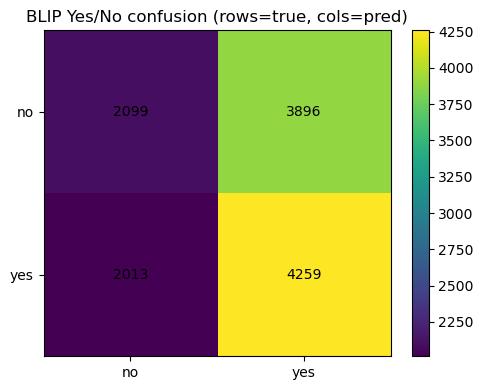

In [10]:
plt.figure(figsize=(5,4))
plt.imshow(cm, aspect="auto")
plt.xticks([0,1], ["no","yes"])
plt.yticks([0,1], ["no","yes"])
plt.title("BLIP Yes/No confusion (rows=true, cols=pred)")
plt.colorbar()
for r in range(2):
    for c in range(2):
        plt.text(c, r, int(cm[r,c]), ha="center", va="center")
plt.tight_layout()
plt.savefig(OUT_DIR / "confusion_matrix.png", dpi=200)
plt.show()